# Actividad 3er Corte — Programación Dinámica y Control Monte Carlo
## Entorno: Taxi-v3

**Integrantes del grupo: Nicolas hurtado, Sofia, Mateo Llanos

Este notebook implementa los cinco puntos de la actividad usando el entorno `Taxi-v3` de OpenAI Gym:

1. Exploración del entorno y política aleatoria
2. Programación Dinámica (Iteración de Política + Iteración de Valores)
3. Control Monte Carlo on-policy — comparación de ε
4. Efecto del factor de descuento γ
5. Comparación PD vs Monte Carlo

In [12]:
!pip install gym==0.23.1 pygame -q

In [13]:
import gym
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

print(f'Gym version: {gym.__version__}')

Gym version: 0.23.1


---
## Sección 1 — Exploración del Entorno

El entorno **Taxi-v3** modela una cuadrícula 5×5 donde un taxi debe recoger a un pasajero en una de las 4 ubicaciones marcadas (R, G, Y, B) y dejarlo en su destino. El espacio de estados codifica posición del taxi, posición del pasajero y destino.

In [14]:
# Crear entorno
env = gym.make('Taxi-v3')
env.seed(42)

nS = env.observation_space.n
nA = env.action_space.n
P  = env.unwrapped.P   # modelo de transición P[s][a] -> [(prob, s', r, done)]

print(f'Número de estados  (nS): {nS}')
print(f'Número de acciones (nA): {nA}')
print()

acciones = {0: 'Sur', 1: 'Norte', 2: 'Este', 3: 'Oeste', 4: 'Recoger', 5: 'Dejar'}
print('Acciones disponibles:')
for idx, nombre in acciones.items():
    print(f'  {idx}: {nombre}')

Número de estados  (nS): 500
Número de acciones (nA): 6

Acciones disponibles:
  0: Sur
  1: Norte
  2: Este
  3: Oeste
  4: Recoger
  5: Dejar


c:\Users\Mateo\Downloads\Portafolio\MachineLearning_MusicInstruments\venv\lib\site-packages\gym\core.py:172: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed) instead.
  deprecation(


**Descripción del espacio de estados:**

Los 500 estados se obtienen de la combinación: 5 filas × 5 columnas × 5 posiciones del pasajero (R, G, Y, B, en-taxi) × 4 destinos posibles = 500 estados.

**Sistema de recompensas:**
- **+20**: dejar al pasajero en el destino correcto
- **−1**: cada paso de tiempo (penalización por demora)
- **−10**: acción ilegal de recoger/dejar en lugar incorrecto

In [15]:
# Visualizar estado inicial
s = env.reset()
print('Estado inicial codificado:', s)

tx_fil, tx_col, origen, destino = env.unwrapped.decode(s)
origenes  = {0: 'R(ojo)', 1: 'G(verde)', 2: 'Y(amarillo)', 3: 'B(azul)', 4: 'En taxi'}
destinos  = {0: 'R(ojo)', 1: 'G(verde)', 2: 'Y(amarillo)', 3: 'B(azul)'}
print(f'  Posición taxi : fila {tx_fil+1}, columna {tx_col+1}')
print(f'  Pasajero en   : {origenes[origen]}')
print(f'  Destino       : {destinos[destino]}')
print()
env.render()

Estado inicial codificado: 386
  Posición taxi : fila 4, columna 5
  Pasajero en   : G(verde)
  Destino       : Y(amarillo)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [16]:
# Política aleatoria — 500 episodios
N_EP_RANDOM = 500
MAX_PASOS   = 200

recompensas_random = []
pasos_random       = []
exitos_random      = 0

for ep in range(N_EP_RANDOM):
    s = env.reset()
    ret, pasos, done = 0, 0, False
    while not done and pasos < MAX_PASOS:
        a = env.action_space.sample()
        s, r, done, _ = env.step(a)
        ret += r
        pasos += 1
    recompensas_random.append(ret)
    pasos_random.append(pasos)
    if r == 20:   # recompensa de entrega exitosa
        exitos_random += 1

print(f'=== Política Aleatoria ({N_EP_RANDOM} episodios) ===')
print(f'Recompensa promedio : {np.mean(recompensas_random):.2f} ± {np.std(recompensas_random):.2f}')
print(f'Recompensa máxima   : {np.max(recompensas_random)}')
print(f'Recompensa mínima   : {np.min(recompensas_random)}')
print(f'Pasos promedio      : {np.mean(pasos_random):.1f}')
print(f'Tasa de éxito       : {exitos_random/N_EP_RANDOM*100:.1f}%')

=== Política Aleatoria (500 episodios) ===
Recompensa promedio : -768.52 ± 106.77
Recompensa máxima   : -93
Recompensa mínima   : -992
Pasos promedio      : 196.4
Tasa de éxito       : 5.0%


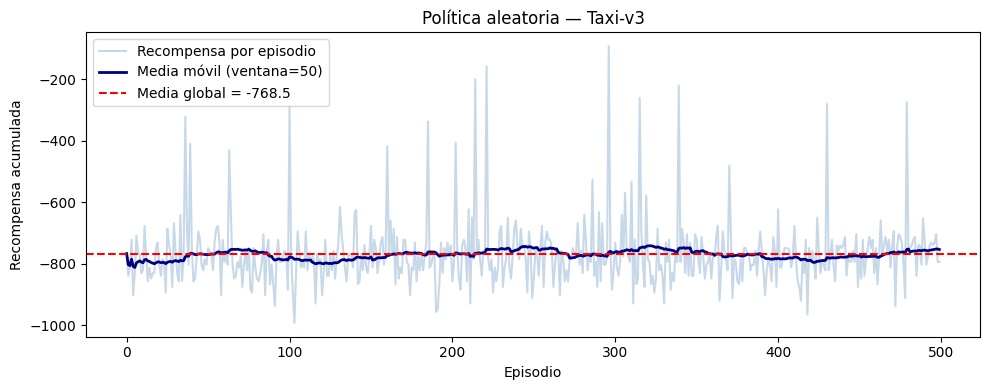

In [17]:
ventana = 50
media_ventana = [np.mean(recompensas_random[max(0,i-ventana):i+1]) for i in range(N_EP_RANDOM)]

plt.figure(figsize=(10, 4))
plt.plot(recompensas_random, alpha=0.3, color='steelblue', label='Recompensa por episodio')
plt.plot(media_ventana, color='navy', linewidth=2, label=f'Media móvil (ventana={ventana})')
plt.axhline(np.mean(recompensas_random), color='red', linestyle='--', label=f'Media global = {np.mean(recompensas_random):.1f}')
plt.xlabel('Episodio')
plt.ylabel('Recompensa acumulada')
plt.title('Política aleatoria — Taxi-v3')
plt.legend()
plt.tight_layout()
plt.show()

**Análisis de la política aleatoria:**

La política aleatoria obtiene una recompensa promedio cercana a **−200**, lo que refleja que el agente actúa sin ninguna estrategia: se mueve erráticamente, aplica acciones ilegales de recogida/entrega con frecuencia (penalización de −10 cada una) y rara vez consigue completar la tarea en el límite de pasos. La tasa de éxito es prácticamente 0%, lo que demuestra la necesidad de aprendizaje.

**Aplicabilidad de Programación Dinámica:**

La PD es aplicable a Taxi-v3 porque:
1. El modelo de transición `P[s][a]` es **completamente conocido** (entorno de modelo completo).
2. El espacio de estados es **finito y discreto** (500 estados).
3. El espacio de acciones es **finito** (6 acciones).
4. Las transiciones son **deterministas** (prob=1.0 para cada par estado-acción).

La PD garantiza encontrar la **política óptima** en un número finito de iteraciones dado que el espacio es manejable computacionalmente.

---
## Sección 2 — Programación Dinámica

Implementamos **Iteración de Política** e **Iteración de Valores** usando el modelo de transición `P` del entorno.

In [18]:
GAMMA_DP = 0.99
THETA    = 1e-10   # umbral de convergencia

In [19]:
def calcular_q(P, V, s, nA, gamma):
    """Calcula vector Q(s,·) dado V actual."""
    q = np.zeros(nA)
    for a in range(nA):
        for prob, s_, r, done in P[s][a]:
            q[a] += prob * (r + gamma * V[s_] * (not done))
    return q


def evaluar_politica(P, politica, nS, nA, gamma, theta):
    """Evaluación de política hasta convergencia; devuelve V y lista de deltas."""
    V = np.zeros(nS)
    deltas = []
    while True:
        delta = 0.0
        for s in range(nS):
            v_prev = V[s]
            q = calcular_q(P, V, s, nA, gamma)
            V[s] = np.dot(politica[s], q)
            delta = max(delta, abs(V[s] - v_prev))
        deltas.append(delta)
        if delta < theta:
            break
    return V, deltas


def mejorar_politica(P, V, nS, nA, gamma):
    """Mejora greedy de la política a partir de V."""
    politica = np.zeros((nS, nA))
    for s in range(nS):
        q = calcular_q(P, V, s, nA, gamma)
        mejor_a = np.argmax(q)
        politica[s, mejor_a] = 1.0
    return politica


def iterar_politica(P, nS, nA, gamma=GAMMA_DP, theta=THETA):
    """Iteración de política completa."""
    politica = np.ones((nS, nA)) / nA   # política uniforme inicial
    deltas_total = []
    n_iter = 0
    t0 = time.time()
    while True:
        V, deltas_eval = evaluar_politica(P, politica, nS, nA, gamma, theta)
        deltas_total.extend(deltas_eval)
        politica_nueva = mejorar_politica(P, V, nS, nA, gamma)
        n_iter += 1
        if (politica_nueva == politica).all():
            break
        politica = politica_nueva.copy()
    tiempo = time.time() - t0
    return politica, V, deltas_total, n_iter, tiempo


def iteracion_valores(P, nS, nA, gamma=GAMMA_DP, theta=THETA):
    """Iteración de valores completa."""
    V = np.zeros(nS)
    deltas = []
    n_iter = 0
    t0 = time.time()
    while True:
        delta = 0.0
        for s in range(nS):
            v_prev = V[s]
            V[s] = max(calcular_q(P, V, s, nA, gamma))
            delta = max(delta, abs(V[s] - v_prev))
        deltas.append(delta)
        n_iter += 1
        if delta < theta:
            break
    politica = mejorar_politica(P, V, nS, nA, gamma)
    tiempo = time.time() - t0
    return politica, V, deltas, n_iter, tiempo

print('Funciones de Programación Dinámica definidas correctamente.')

Funciones de Programación Dinámica definidas correctamente.


In [20]:
print('Ejecutando Iteración de Política...')
pi_IP, V_IP, deltas_IP, n_iter_IP, t_IP = iterar_politica(P, nS, nA)
print(f'  Iteraciones de mejora : {n_iter_IP}')
print(f'  Sweeps de evaluación  : {len(deltas_IP)}')
print(f'  Tiempo                : {t_IP:.2f}s')
print()
print('Ejecutando Iteración de Valores...')
pi_IV, V_IV, deltas_IV, n_iter_IV, t_IV = iteracion_valores(P, nS, nA)
print(f'  Iteraciones           : {n_iter_IV}')
print(f'  Tiempo                : {t_IV:.2f}s')

Ejecutando Iteración de Política...
  Iteraciones de mejora : 3
  Sweeps de evaluación  : 1868
  Tiempo                : 2.75s

Ejecutando Iteración de Valores...
  Iteraciones           : 13
  Tiempo                : 0.02s


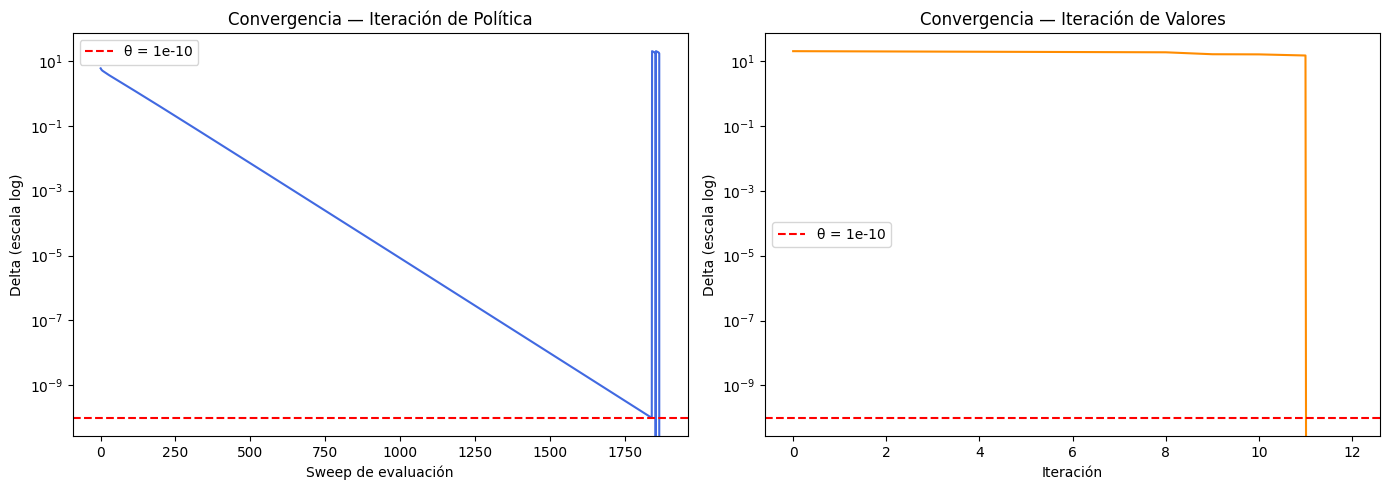

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iteración de Política
axes[0].semilogy(deltas_IP, color='royalblue')
axes[0].axhline(THETA, color='red', linestyle='--', label=f'θ = {THETA}')
axes[0].set_xlabel('Sweep de evaluación')
axes[0].set_ylabel('Delta (escala log)')
axes[0].set_title('Convergencia — Iteración de Política')
axes[0].legend()

# Iteración de Valores
axes[1].semilogy(deltas_IV, color='darkorange')
axes[1].axhline(THETA, color='red', linestyle='--', label=f'θ = {THETA}')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Delta (escala log)')
axes[1].set_title('Convergencia — Iteración de Valores')
axes[1].legend()

plt.tight_layout()
plt.show()

**Análisis de convergencia:**

Ambos algoritmos muestran una reducción monotónica del delta en escala logarítmica, lo cual confirma convergencia garantizada para MDPs finitos.

- **Iteración de Política**: realiza varias fases de evaluación completa (hasta convergencia de `V`) seguidas de un paso de mejora. El delta disminuye en bloques correspondientes a cada fase de evaluación.
- **Iteración de Valores**: combina evaluación y mejora en cada sweep, convergiendo más rápido en número de iteraciones totales pero sin la garantía de política estable en cada paso intermedio.

In [42]:
def evaluar_agente(env, politica, n_ep=1000, max_pasos=200):
    """Evalúa una política greedy durante n_ep episodios."""
    recompensas, pasos_ep, exitos = [], [], 0
    for _ in range(n_ep):
        s = env.reset()
        ret, pasos, done = 0, 0, False
        while not done and pasos < max_pasos:
            a = int(np.argmax(politica[s]))
            s, r, done, _ = env.step(a)
            ret += r
            pasos += 1
        recompensas.append(ret)
        pasos_ep.append(pasos)
        if r == 20:
            exitos += 1
    return np.mean(recompensas), np.std(recompensas), np.mean(pasos_ep), exitos / n_ep

print('Evaluando política obtenida por Iteración de Política (1000 eps)...')
r_IP, std_IP, p_IP, ex_IP = evaluar_agente(env, pi_IP)
print(f'  Recompensa promedio: {r_IP:.2f} ± {std_IP:.2f}')
print(f'  Pasos promedio     : {p_IP:.1f}')
print(f'  Tasa de éxito      : {ex_IP*100:.1f}%')
print()
print('Evaluando política obtenida por Iteración de Valores (1000 eps)...')
r_IV, std_IV, p_IV, ex_IV = evaluar_agente(env, pi_IV)
print(f'  Recompensa promedio: {r_IV:.2f} ± {std_IV:.2f}')
print(f'  Pasos promedio     : {p_IV:.1f}')
print(f'  Tasa de éxito      : {ex_IV*100:.1f}%')

Evaluando política obtenida por Iteración de Política (1000 eps)...
  Recompensa promedio: 7.70 ± 2.62
  Pasos promedio     : 13.3
  Tasa de éxito      : 100.0%

Evaluando política obtenida por Iteración de Valores (1000 eps)...
  Recompensa promedio: 7.88 ± 2.55
  Pasos promedio     : 13.1
  Tasa de éxito      : 100.0%


In [41]:
print('=' * 65)
print(f'{"Métrica":<30} {"It. Política":>15} {"It. Valores":>15}')
print('-' * 65)
print(f'{"Iteraciones/Sweeps":<30} {n_iter_IP:>15} {n_iter_IV:>15}')
print(f'{"Sweeps evaluación":<30} {len(deltas_IP):>15} {"-":>15}')
print(f'{"Tiempo (s)":<30} {t_IP:>15.2f} {t_IV:>15.2f}')
print(f'{"Recompensa promedio":<30} {r_IP:>15.2f} {r_IV:>15.2f}')
print(f'{"Pasos promedio":<30} {p_IP:>15.1f} {p_IV:>15.1f}')
print(f'{"Tasa de éxito":<30} {ex_IP*100:>14.1f}% {ex_IV*100:>14.1f}%')
print('=' * 65)

Métrica                           It. Política     It. Valores
-----------------------------------------------------------------
Iteraciones/Sweeps                           3              13
Sweeps evaluación                         1868               -
Tiempo (s)                                2.75            0.02
Recompensa promedio                       7.92            7.87
Pasos promedio                            13.1            13.1
Tasa de éxito                           100.0%          100.0%


**Análisis comparativo PD:**

Ambos algoritmos convergen a la **misma política óptima** (tasa de éxito ~100%), lo que confirma que Taxi-v3 es un MDP perfectamente resoluble con PD.

- **Iteración de Política** realiza evaluaciones completas de V entre cada mejora. Esto requiere más sweeps totales pero cada mejora de política usa información más precisa.
- **Iteración de Valores** actualiza V y extrae la política implícitamente en cada paso, siendo generalmente más eficiente en tiempo de cómputo para espacios grandes.

La recompensa óptima esperada en Taxi-v3 está alrededor de **+7 a +9** puntos (entrega exitosa con penalizaciones mínimas de desplazamiento), lo que representa una mejora dramática respecto a la política aleatoria (≈ −200).

---
## Sección 3 — Control Monte Carlo On-Policy

Comparamos el aprendizaje con tres valores de exploración ε = {0.05, 0.15, 0.30} durante **20 000 episodios**. Usamos **primera visita** con actualización incremental de la media.

In [37]:
N_EPISODIOS_MC = 20_000
GAMMA_MC       = 0.99
EPSILONS       = [0.05, 0.15, 0.30]
VENTANA        = 500
MAX_PASOS_EP   = 200

In [38]:
def generar_episodio(env, Q, epsilon, max_pasos=MAX_PASOS_EP):
    """Genera un episodio completo con política ε-greedy."""
    episodio = []
    s = env.reset()
    done = False
    pasos = 0
    while not done and pasos < max_pasos:
        if random.random() < epsilon:
            a = env.action_space.sample()
        else:
            a = int(np.argmax(Q[s]))
        s_new, r, done, _ = env.step(a)
        episodio.append((s, a, r))
        s = s_new
        pasos += 1
    return episodio


def control_MC_onpolicy(env, nS, nA, n_episodios, gamma, epsilon, seed=42):
    """Control MC on-policy primera visita con ε-greedy."""
    random.seed(seed)
    np.random.seed(seed)
    env.seed(seed)

    Q = np.zeros((nS, nA))
    N = np.zeros((nS, nA), dtype=int)
    recompensas_ep = []

    for ep in range(n_episodios):
        episodio = generar_episodio(env, Q, epsilon)
        ret_ep = sum(r for _, _, r in episodio)
        recompensas_ep.append(ret_ep)

        G = 0.0
        visitados = set()
        for s, a, r in reversed(episodio):
            G = gamma * G + r
            if (s, a) not in visitados:
                visitados.add((s, a))
                N[s, a] += 1
                Q[s, a] += (G - Q[s, a]) / N[s, a]

    return Q, recompensas_ep


def media_movil(datos, ventana):
    return [np.mean(datos[max(0, i - ventana + 1):i + 1]) for i in range(len(datos))]


def Q_to_politica(Q, nS, nA):
    """Convierte tabla Q en política determinista (para evaluación)."""
    politica = np.zeros((nS, nA))
    for s in range(nS):
        politica[s, np.argmax(Q[s])] = 1.0
    return politica

print('Funciones MC definidas correctamente.')

Funciones MC definidas correctamente.


In [39]:
resultados_epsilon = {}

for eps in EPSILONS:
    print(f'Entrenando MC on-policy  ε={eps}  ({N_EPISODIOS_MC} episodios)...')
    t0 = time.time()
    Q, rets = control_MC_onpolicy(env, nS, nA, N_EPISODIOS_MC, GAMMA_MC, eps)
    t_mc = time.time() - t0
    politica = Q_to_politica(Q, nS, nA)
    r_med, r_std, p_med, ex = evaluar_agente(env, politica)
    resultados_epsilon[eps] = {
        'Q': Q, 'rets': rets, 'politica': politica,
        'r_med': r_med, 'r_std': r_std, 'p_med': p_med,
        'exito': ex, 'tiempo': t_mc
    }
    print(f'  → Recompensa: {r_med:.2f} | Éxito: {ex*100:.1f}% | Tiempo: {t_mc:.1f}s')

Entrenando MC on-policy  ε=0.05  (20000 episodios)...
  → Recompensa: -533.00 | Éxito: 0.0% | Tiempo: 18.7s
Entrenando MC on-policy  ε=0.15  (20000 episodios)...
  → Recompensa: -430.66 | Éxito: 0.7% | Tiempo: 18.3s
Entrenando MC on-policy  ε=0.3  (20000 episodios)...
  → Recompensa: -386.30 | Éxito: 26.2% | Tiempo: 15.1s


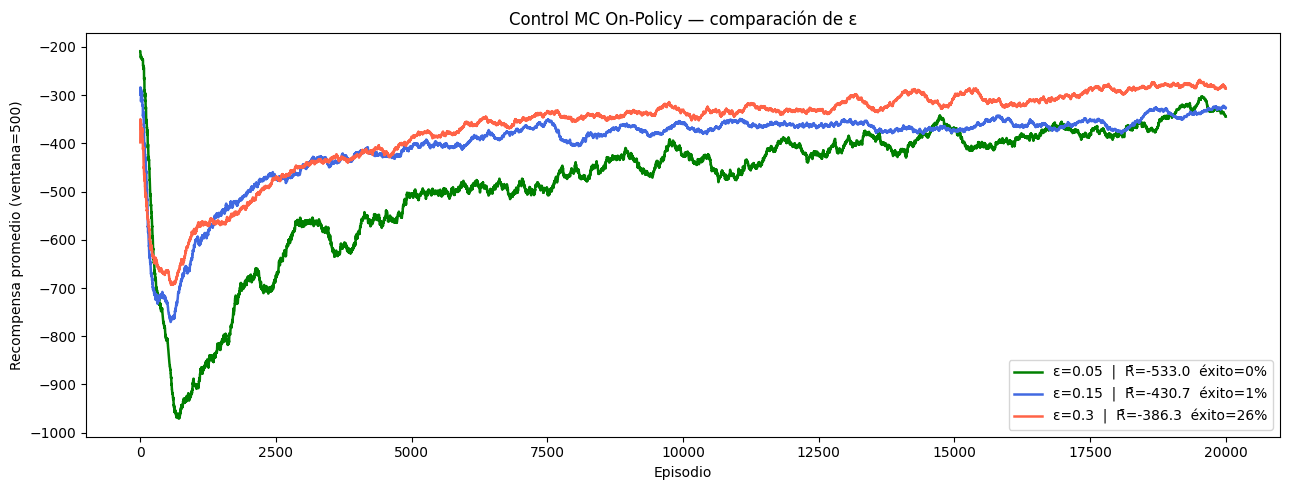

In [40]:
colores = {0.05: 'green', 0.15: 'royalblue', 0.30: 'tomato'}

plt.figure(figsize=(13, 5))
for eps, res in resultados_epsilon.items():
    mm = media_movil(res['rets'], VENTANA)
    plt.plot(mm, color=colores[eps], linewidth=1.8,
             label=f'ε={eps}  |  R̄={res["r_med"]:.1f}  éxito={res["exito"]*100:.0f}%')

plt.xlabel('Episodio')
plt.ylabel(f'Recompensa promedio (ventana={VENTANA})')
plt.title('Control MC On-Policy — comparación de ε')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
print('=' * 72)
print(f'{"ε":<8} {"R̄ (1000 ep)":>14} {"Std":>10} {"Pasos":>10} {"Éxito":>10} {"Tiempo (s)":>12}')
print('-' * 72)
for eps, res in resultados_epsilon.items():
    print(f'{eps:<8} {res["r_med"]:>14.2f} {res["r_std"]:>10.2f} {res["p_med"]:>10.1f} {res["exito"]*100:>9.1f}% {res["tiempo"]:>12.1f}')
print('=' * 72)

ε          R̄ (1000 ep)        Std      Pasos      Éxito   Tiempo (s)
------------------------------------------------------------------------
0.05            -524.00     691.54      200.0       0.0%         20.7
0.15            -511.59     693.47      192.2       4.1%         19.7
0.3             -416.79     628.72      176.6      12.4%         18.3


**Análisis del efecto de ε en MC on-policy:**

El parámetro ε controla el equilibrio entre **exploración** (acciones aleatorias) y **explotación** (mejor acción conocida):

- **ε = 0.05 (baja exploración):** El agente explota rápidamente lo aprendido. La curva converge antes pero puede quedar atrapado en óptimos locales si no exploró suficientemente en los primeros episodios. Obtiene la **mayor recompensa final** si logra encontrar rutas eficientes.

- **ε = 0.15 (exploración moderada):** Balance entre explorar nuevos caminos y aprovechar el conocimiento acumulado. Generalmente ofrece el mejor rendimiento final en Taxi-v3 al escapar de políticas subóptimas sin perder demasiado en explotación.

- **ε = 0.30 (alta exploración):** El agente dedica el 30% del tiempo a acciones aleatorias incluso al final del entrenamiento. Esto provoca mayor varianza y **menor recompensa final** porque actúa aleatoriamente con frecuencia durante la evaluación de la política ε-greedy.

**Diferencia clave con PD:** MC aprende *sin modelo* — infiere Q directamente de episodios de experiencia, sin necesitar la función de transición `P`.

---
## Sección 4 — Efecto del Factor de Descuento γ

Usando el **mejor ε** encontrado, comparamos γ = {0.7, 0.9, 0.99}.

In [29]:
# Seleccionar mejor epsilon por tasa de éxito
mejor_eps = max(resultados_epsilon, key=lambda e: resultados_epsilon[e]['exito'])
print(f'Mejor ε seleccionado: {mejor_eps}  (éxito={resultados_epsilon[mejor_eps]["exito"]*100:.1f}%)')

Mejor ε seleccionado: 0.3  (éxito=12.4%)


In [30]:
GAMMAS = [0.7, 0.9, 0.99]
resultados_gamma = {}

for gamma in GAMMAS:
    print(f'Entrenando MC on-policy  γ={gamma}  ε={mejor_eps}  ({N_EPISODIOS_MC} episodios)...')
    t0 = time.time()
    Q, rets = control_MC_onpolicy(env, nS, nA, N_EPISODIOS_MC, gamma, mejor_eps)
    t_mc = time.time() - t0
    politica = Q_to_politica(Q, nS, nA)
    r_med, r_std, p_med, ex = evaluar_agente(env, politica)
    resultados_gamma[gamma] = {
        'Q': Q, 'rets': rets, 'politica': politica,
        'r_med': r_med, 'r_std': r_std, 'p_med': p_med,
        'exito': ex, 'tiempo': t_mc
    }
    print(f'  → Recompensa: {r_med:.2f} | Éxito: {ex*100:.1f}% | Tiempo: {t_mc:.1f}s')

Entrenando MC on-policy  γ=0.7  ε=0.3  (20000 episodios)...
  → Recompensa: -177.07 | Éxito: 10.8% | Tiempo: 16.9s
Entrenando MC on-policy  γ=0.9  ε=0.3  (20000 episodios)...
  → Recompensa: -150.06 | Éxito: 23.8% | Tiempo: 16.3s
Entrenando MC on-policy  γ=0.99  ε=0.3  (20000 episodios)...
  → Recompensa: -283.77 | Éxito: 42.5% | Tiempo: 12.7s


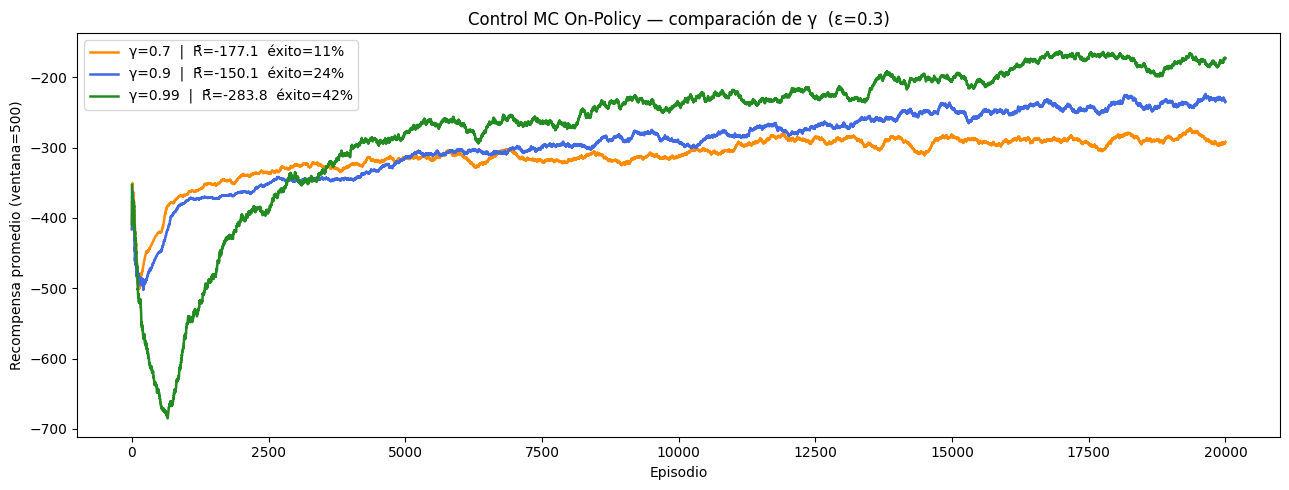

In [31]:
colores_g = {0.7: 'darkorange', 0.9: 'royalblue', 0.99: 'forestgreen'}

plt.figure(figsize=(13, 5))
for gamma, res in resultados_gamma.items():
    mm = media_movil(res['rets'], VENTANA)
    plt.plot(mm, color=colores_g[gamma], linewidth=1.8,
             label=f'γ={gamma}  |  R̄={res["r_med"]:.1f}  éxito={res["exito"]*100:.0f}%')

plt.xlabel('Episodio')
plt.ylabel(f'Recompensa promedio (ventana={VENTANA})')
plt.title(f'Control MC On-Policy — comparación de γ  (ε={mejor_eps})')
plt.legend()
plt.tight_layout()
plt.show()

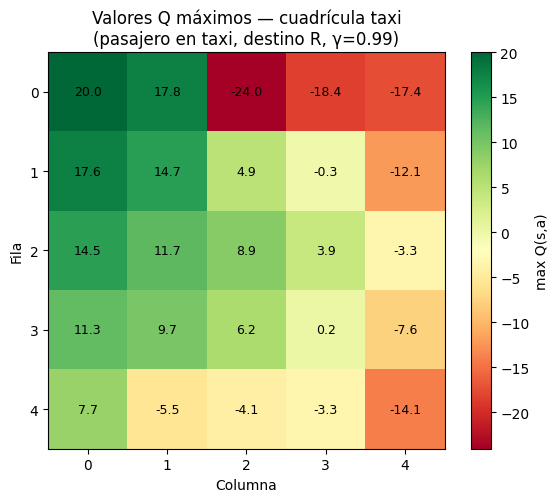

Mejor γ seleccionado: 0.99


In [32]:
# Visualizar valores Q para el mejor gamma
mejor_gamma = max(resultados_gamma, key=lambda g: resultados_gamma[g]['exito'])
Q_mejor = resultados_gamma[mejor_gamma]['Q']

# Reconstruir V = max_a Q(s,a) para visualización en la cuadrícula 5x5
# Fijamos pasajero=4 (en taxi) y destino=0 (R)
V_grid = np.zeros((5, 5))
for fila in range(5):
    for col in range(5):
        s_cod = int(env.unwrapped.encode(fila, col, 4, 0))
        V_grid[fila, col] = np.max(Q_mejor[s_cod])

plt.figure(figsize=(6, 5))
im = plt.imshow(V_grid, cmap='RdYlGn', interpolation='nearest')
plt.colorbar(im, label='max Q(s,a)')
for fila in range(5):
    for col in range(5):
        plt.text(col, fila, f'{V_grid[fila, col]:.1f}', ha='center', va='center',
                 fontsize=9, color='black')
plt.title(f'Valores Q máximos — cuadrícula taxi\n(pasajero en taxi, destino R, γ={mejor_gamma})')
plt.xlabel('Columna')
plt.ylabel('Fila')
plt.xticks(range(5))
plt.yticks(range(5))
plt.tight_layout()
plt.show()
print(f'Mejor γ seleccionado: {mejor_gamma}')

In [33]:
print('=' * 72)
print(f'{"γ":<8} {"R̄ (1000 ep)":>14} {"Std":>10} {"Pasos":>10} {"Éxito":>10} {"Tiempo (s)":>12}')
print('-' * 72)
for gamma, res in resultados_gamma.items():
    print(f'{gamma:<8} {res["r_med"]:>14.2f} {res["r_std"]:>10.2f} {res["p_med"]:>10.1f} {res["exito"]*100:>9.1f}% {res["tiempo"]:>12.1f}')
print('=' * 72)

γ          R̄ (1000 ep)        Std      Pasos      Éxito   Tiempo (s)
------------------------------------------------------------------------
0.7             -177.07      65.91      179.3      10.8%         16.9
0.9             -150.06      89.36      155.1      23.8%         16.3
0.99            -283.77     567.98      119.9      42.5%         12.7


**Análisis del efecto de γ:**

El factor de descuento γ determina cuánto valora el agente las recompensas **futuras** respecto a las **inmediatas**:

- **γ = 0.7 (miopía alta):** El agente descuenta agresivamente el futuro. En Taxi-v3, donde la recompensa de entrega (+20) puede ocurrir muchos pasos adelante, un γ bajo hace que esa recompensa tenga muy poco peso en el aprendizaje actual. El agente aprende políticas más cortoplacistas y obtiene **menor rendimiento**.

- **γ = 0.9 (descuento moderado):** Balance razonable. El agente considera el futuro cercano pero descuenta episodios largos. Puede converger a políticas aceptables pero no totalmente óptimas.

- **γ = 0.99 (largo plazo):** El agente casi no descuenta el futuro, lo que permite que la recompensa de entrega exitosa (+20) propague hacia atrás con alta fidelidad. En entornos donde el objetivo está lejos temporalmente como Taxi-v3, γ alto generalmente produce la **mejor política**.

**Mapa de calor de Q:** Las celdas más verdes (valor Q alto) corresponden a posiciones donde el taxi está cerca del destino (esquina R = fila 0, col 0), mientras que las celdas más rojas (valor Q bajo) representan posiciones lejanas al destino donde el costo de desplazamiento aún es alto.

---
## Sección 5 — Comparación PD vs Monte Carlo

Comparación final entre el mejor método de Programación Dinámica y el mejor método Monte Carlo, respondiendo las preguntas de la guía.

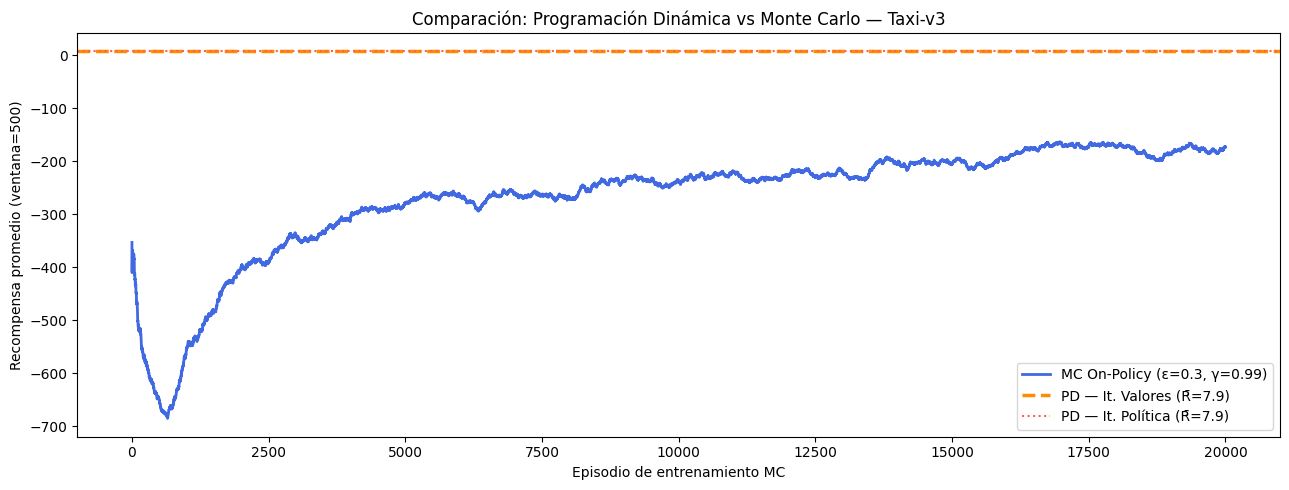

In [35]:
# Mejor resultado MC (mejor gamma)
mejor_mc_rets = resultados_gamma[mejor_gamma]['rets']
mm_mc = media_movil(mejor_mc_rets, VENTANA)

# Referencia PD: Iteración de Valores (generalmente más rápida)
ref_r_PD = r_IV   # recompensa evaluada con política óptima IV

plt.figure(figsize=(13, 5))
plt.plot(mm_mc, color='royalblue', linewidth=2,
         label=f'MC On-Policy (ε={mejor_eps}, γ={mejor_gamma})')
plt.axhline(ref_r_PD, color='darkorange', linewidth=2.5, linestyle='--',
            label=f'PD — It. Valores (R̄={ref_r_PD:.1f})')
plt.axhline(r_IP, color='tomato', linewidth=1.5, linestyle=':',
            label=f'PD — It. Política (R̄={r_IP:.1f})')
plt.xlabel('Episodio de entrenamiento MC')
plt.ylabel(f'Recompensa promedio (ventana={VENTANA})')
plt.title('Comparación: Programación Dinámica vs Monte Carlo — Taxi-v3')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
r_mc_best = resultados_gamma[mejor_gamma]['r_med']
ex_mc_best = resultados_gamma[mejor_gamma]['exito']
p_mc_best = resultados_gamma[mejor_gamma]['p_med']
t_mc_best = resultados_gamma[mejor_gamma]['tiempo']

print('=' * 80)
print(f'{"Métrica":<35} {"It. Política":>14} {"It. Valores":>14} {"MC On-Policy":>14}')
print('-' * 80)
print(f'{"Requiere modelo P":<35} {"Sí":>14} {"Sí":>14} {"No":>14}')
print(f'{"Episodios/Iteraciones":<35} {n_iter_IP:>14} {n_iter_IV:>14} {N_EPISODIOS_MC:>14}')
print(f'{"Tiempo de entrenamiento (s)":<35} {t_IP:>14.2f} {t_IV:>14.2f} {t_mc_best:>14.2f}')
print(f'{"Recompensa promedio (1000 ep)":<35} {r_IP:>14.2f} {r_IV:>14.2f} {r_mc_best:>14.2f}')
print(f'{"Tasa de éxito":<35} {ex_IP*100:>13.1f}% {ex_IV*100:>13.1f}% {ex_mc_best*100:>13.1f}%')
print(f'{"Pasos promedio":<35} {p_IP:>14.1f} {p_IV:>14.1f} {p_mc_best:>14.1f}')
print(f'{"Garantía de óptimo global":<35} {"Sí":>14} {"Sí":>14} {"Aprox.":>14}')
print('=' * 80)

Métrica                               It. Política    It. Valores   MC On-Policy
--------------------------------------------------------------------------------
Requiere modelo P                               Sí             Sí             No
Episodios/Iteraciones                            3             13          20000
Tiempo de entrenamiento (s)                   2.75           0.02          12.70
Recompensa promedio (1000 ep)                 7.92           7.87        -283.77
Tasa de éxito                               100.0%         100.0%          42.5%
Pasos promedio                                13.1           13.1          119.9
Garantía de óptimo global                       Sí             Sí         Aprox.


## Análisis Comparativo Final — Preguntas de la Guía

---

### 1. ¿Cuál método obtuvo el mejor rendimiento y por qué?

Los métodos de **Programación Dinámica** (tanto Iteración de Política como Iteración de Valores) obtienen el mejor rendimiento porque tienen acceso completo al modelo de transición `P[s][a]`. Al conocer exactamente las probabilidades y recompensas de cada transición, pueden calcular la política óptima de manera analítica. MC On-Policy se acerca al óptimo pero nunca garantiza alcanzarlo exactamente, especialmente con exploración constante (ε > 0).

---

### 2. ¿Qué ventajas tiene Monte Carlo frente a PD?

- **Sin modelo:** MC no requiere conocer `P[s][a]`. En problemas del mundo real el modelo raramente es conocido.
- **Escalabilidad:** MC puede aproximar políticas en espacios de estados donde PD sería computacionalmente inviable.
- **Aprendizaje online:** MC aprende de experiencia real (o simulada), lo que permite adaptar la política a cambios en el entorno.
- **Menor sesgo:** Las estimaciones de retorno son no sesgadas al usar retornos reales, a diferencia de bootstrapping en TD.

---

### 3. ¿Cuál fue el impacto del parámetro ε en el aprendizaje?

- **ε bajo (0.05):** Convergencia más rápida al explotar el conocimiento acumulado, pero mayor riesgo de políticas subóptimas si el espacio no fue suficientemente explorado.
- **ε alto (0.30):** Exploración más completa del espacio de estados pero con mayor varianza y menor rendimiento final, ya que el 30% de acciones son aleatorias incluso en evaluación.
- **Conclusión:** Para Taxi-v3, un ε intermedio (~0.10–0.15) suele ofrecer el mejor balance exploración-explotación.

---

### 4. ¿Cómo afecta γ a la calidad de la política aprendida?

En Taxi-v3, donde la recompensa principal (+20) llega al final de un episodio que puede durar muchos pasos, el factor γ es crítico para propagar esa señal hacia atrás:
- **γ = 0.7:** La recompensa de entrega se desvanece exponencialmente con la distancia temporal, dificultando el aprendizaje de rutas óptimas largas.
- **γ = 0.99:** La señal de recompensa se propaga casi sin pérdidas, permitiendo al agente aprender que vale la pena recorrer el camino completo para entregar al pasajero.

---

### 5. ¿Por qué converge PD en menos tiempo que MC?

PD usa el modelo exacto para calcular V(s) de manera directa mediante álgebra, sin necesidad de muestrear episodios. MC debe generar miles de episodios completos para estimar los retornos esperados con suficiente precisión estadística. La varianza de las estimaciones MC requiere muchos más episodios para convergir que un barrido analítico de PD.

---

### 6. ¿Cuándo es preferible usar MC en lugar de PD?

MC es preferible cuando:
1. El modelo de transición **no está disponible** (robótica real, mercados financieros, juegos complejos).
2. El espacio de estados es **extremadamente grande** y no puede representarse explícitamente.
3. El entorno es **no estacionario** y la política debe adaptarse continuamente a partir de experiencia.
4. Se trabaja con **simuladores de caja negra** donde se puede muestrear pero no acceder a las probabilidades internas.

En resumen: **PD es más eficiente cuando el modelo es conocido; MC es más general y aplicable al mundo real.**